# Z-Test

This notebook demonstrates a one-sample Z-Test for a population mean.

We will work through two examples:

1. Average height
2. Bulb warranty life

The notebook demonstrates both:

- Critical-value approach
- P-value approach

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Example 1 — Average Height

Given:

- Population mean: $\mu_0 = 168$ cm
- Population standard deviation: $\sigma = 3.9$ cm
- Sample size: $n = 36$
- Sample mean: $\bar{x} = 169.5$ cm
- Confidence level: 95%

Hypotheses:

$$
H_0: \mu = 168
$$

$$
H_1: \mu \neq 168
$$

This is a two-tailed test.

In [3]:
mu_0 = 168
sigma = 3.9
n = 36
x_bar = 169.5
alpha = 0.05

standard_error = sigma / math.sqrt(n)

z_stat = (x_bar - mu_0) / standard_error

print("Standard Error:", standard_error)
print("Z-statistic:", z_stat)

Standard Error: 0.65
Z-statistic: 2.3076923076923075


## Critical-Value Approach

For a two-tailed test with:

$$
\alpha = 0.05
$$

the critical values are:

$$
Z = \pm 1.96
$$

In [4]:
critical_value = stats.norm.ppf(1 - alpha / 2)

print("Lower Critical Value:", -critical_value)
print("Upper Critical Value:", critical_value)

if abs(z_stat) > critical_value:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to Reject H₀")

Lower Critical Value: -1.959963984540054
Upper Critical Value: 1.959963984540054
Decision: Reject H₀


## P-Value Approach

Because this is a two-tailed test:

$$
p = 2P(Z \geq |z|)
$$

In [5]:
p_value = 2 * stats.norm.sf(abs(z_stat))

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to Reject H₀")

Z-statistic: 2.3076923076923075
P-value: 0.021016256227518675
Decision: Reject H₀


## Visualizing the Two-Tailed Test

The rejection regions contain the extreme 5% of the standard normal distribution:

- 2.5% in the left tail
- 2.5% in the right tail

The critical values are approximately:

$$
-1.96,\quad +1.96
$$

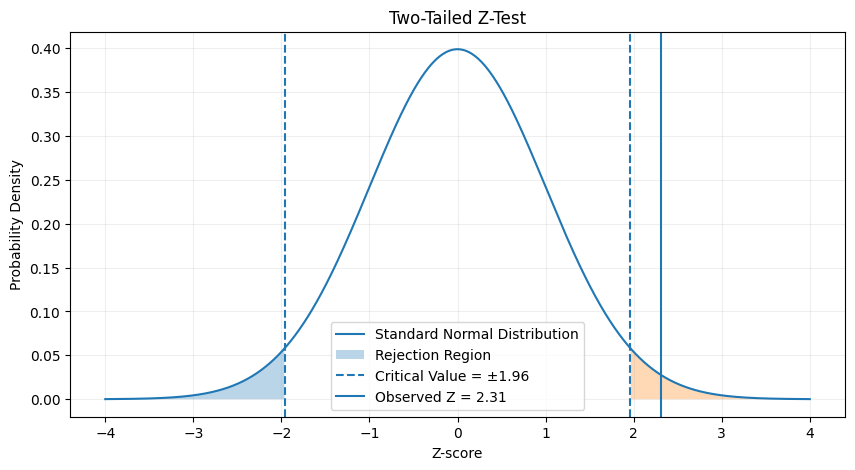

In [6]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label="Standard Normal Distribution")

left = x <= -critical_value
right = x >= critical_value

plt.fill_between(
    x[left],
    y[left],
    alpha=0.3,
    label="Rejection Region"
)

plt.fill_between(
    x[right],
    y[right],
    alpha=0.3
)

plt.axvline(
    -critical_value,
    linestyle="--",
    label=f"Critical Value = ±{critical_value:.2f}"
)

plt.axvline(
    critical_value,
    linestyle="--"
)

plt.axvline(
    z_stat,
    linestyle="-",
    label=f"Observed Z = {z_stat:.2f}"
)

plt.xlabel("Z-score")
plt.ylabel("Probability Density")
plt.title("Two-Tailed Z-Test")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## Example 2 — Bulb Warranty

Given:

- Population mean: $\mu_0 = 5$ years
- Population standard deviation: $\sigma = 0.50$ years
- Sample size: $n = 40$
- Sample mean: $\bar{x} = 4.8$ years
- Confidence level: 98%

Hypotheses:

$$
H_0: \mu = 5
$$

$$
H_1: \mu < 5
$$

This is a **left-tailed test**.

In [7]:
mu_0 = 5
sigma = 0.50
n = 40
x_bar = 4.8
alpha = 0.02

standard_error = sigma / math.sqrt(n)

z_stat = (x_bar - mu_0) / standard_error

print("Standard Error:", standard_error)
print("Z-statistic:", z_stat)

Standard Error: 0.07905694150420949
Z-statistic: -2.5298221281347057


## P-Value for the Left-Tailed Test

For a left-tailed test:

$$
p = P(Z \leq z)
$$

In [8]:
p_value = stats.norm.cdf(z_stat)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to Reject H₀")

Z-statistic: -2.5298221281347057
P-value: 0.0057060181930007866
Decision: Reject H₀


## Left-Tailed Test Visualization

The rejection region is located entirely in the left tail.

The significance level is:

$$
\alpha = 0.02
$$

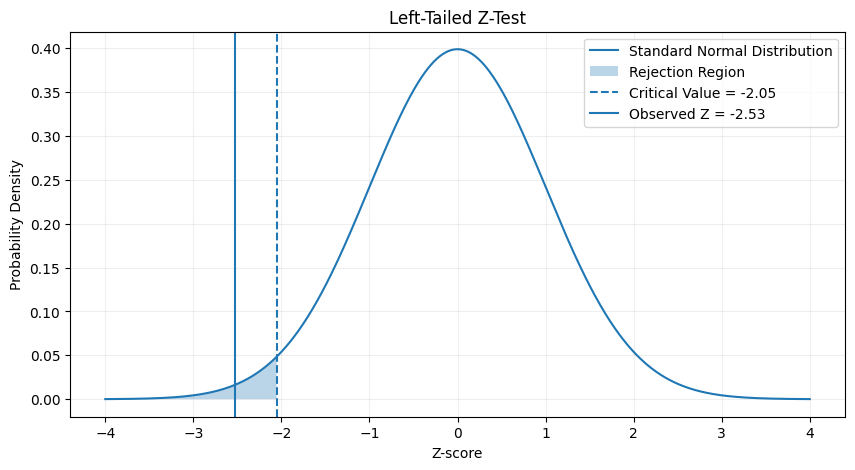

In [9]:
critical_value = stats.norm.ppf(alpha)

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label="Standard Normal Distribution")

rejection_region = x <= critical_value

plt.fill_between(
    x[rejection_region],
    y[rejection_region],
    alpha=0.3,
    label="Rejection Region"
)

plt.axvline(
    critical_value,
    linestyle="--",
    label=f"Critical Value = {critical_value:.2f}"
)

plt.axvline(
    z_stat,
    linestyle="-",
    label=f"Observed Z = {z_stat:.2f}"
)

plt.xlabel("Z-score")
plt.ylabel("Probability Density")
plt.title("Left-Tailed Z-Test")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Final Summary

### Example 1

Two-tailed test:

$$
H_1: \mu \neq 168
$$

$$
Z \approx 2.31
$$

$$
p \approx 0.0209
$$

Since:

$$
p < 0.05
$$

**Reject $H_0$.**

---

### Example 2

Left-tailed test:

$$
H_1: \mu < 5
$$

$$
Z \approx -2.53
$$

$$
p \approx 0.0057
$$

Since:

$$
p < 0.02
$$

**Reject $H_0$.**

### General Decision Rule

$$
p < \alpha
\Rightarrow
\text{Reject } H_0
$$

$$
p \geq \alpha
\Rightarrow
\text{Fail to Reject } H_0
$$